In [223]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from astropy.io import fits

In [ ]:
df6_one = fits.open("VII_259_6dfgs.dat.gz.fits")[1]
df6_one_columns = df6_one.columns
df6_one_data = df6_one.data
df6_one_columns

df6_1 = pd.DataFrame(df6_one_data)
df6_1.head()

,6dFGS,RAh,RAm,RAs,DE-,DEd,DEm,DEs,Nm,Nz,...,r_cz,q_cz,GLON,GLAT,AV,w,Target,Template,FileName,SpecID
0,g0000026-232205,0,0,2.58,-,23,22,4.9,1,1,...,126,4,48.04,-77.79,0.06,8,2,1,0007m230VRredz2,758
1,g0000033-360504,0,0,3.28,-,36,5,4.0,2,2,...,126,4,350.39,-75.88,0.05,8,3,3:3,2359m364VRredz2,917:117199
2,g0000042-522157,0,0,4.22,-,52,21,57.1,1,1,...,126,4,320.32,-62.99,0.05,8,4,2,0009m510VRredz2,1102
3,g0000043-501834,0,0,4.26,-,50,18,34.4,1,1,...,126,4,322.43,-64.83,0.05,8,5,2,0009m510VRredz2,1124
4,g0000044-000500,0,0,4.43,-,0,5,0.0,0,0,...,5,9,96.30,-60.27,0.11,8,6,Z,ZCAT,0


In [225]:
df6_two = np.loadtxt("df6_spectra.txt", delimiter="|", dtype="str", skiprows=6)
two_columns = "SpecID|Target|6dFGS|RA-DEC|dr|zraw|z|q_z|Rcor|ExpV|MJD.V|ExpR|MJD.R|Com".split("|")

df6_2 = pd.DataFrame(df6_two, columns=two_columns)
df6_2.head()

,SpecID,Target,6dFGS,RA-DEC,dr,zraw,z,q_z,Rcor,ExpV,MJD.V,ExpR,MJD.R,Com
0,1,104,g0000531-300714,00:00:53.07 -30:07:14.0,0.001,0.03975,0.03981,1,3.92,1200,52846.78,600,52846.82,
1,2,127050,g0001032-291829,00:01:03.23 -29:18:29.1,0.001,2.28448,2.28448,1,8.89,1200,52846.78,600,52846.82,
2,3,168322,g2359150-300636,23:59:14.98 -30:06:36.2,0.001,2.28377,2.28377,1,5.30,1200,52846.78,600,52846.82,
3,4,113826,g2358173-300641,23:58:17.26 -30:06:41.2,0.001,0.02961,0.02967,4,9.21,1200,52846.78,600,52846.82,
4,5,127047,g2358428-293647,23:58:42.75 -29:36:46.7,0.001,0.06070,0.06076,4,7.11,1200,52846.78,600,52846.82,


In [226]:
# SET THE COORDS

df6_1_ra = df6_1["RAh"] * 360/24 + df6_1["RAm"] * 360 / (24*60) + df6_1["RAs"] * 360 / (24*3600)
df6_1["RA"] = df6_1_ra

df6_1_dec_sign = 1 + (-2) * (df6_1["DE-"] == "-")
df6_1_dec = df6_1["DEd"] + df6_1["DEm"] / 60 + df6_1["DEs"] / 3600
df6_1["DEC"] = df6_1_dec_sign * df6_1_dec

In [227]:
df6_2["Target"] = np.int_(df6_2["Target"])
df6_2["z"] = np.float32(df6_2["z"])
df6_2["q_z"] = np.int_(df6_2["q_z"])

In [228]:
# CHOOSE RELEVANT LINES
df6_1_trunc = df6_1[["Target", "RA", "DEC", "GLON", "GLAT"]]
df6_1_trunc.head()

,Target,RA,DEC,GLON,GLAT
0,2,0.010750,-23.368028,48.04,-77.79
1,3,0.013667,-36.084444,350.39,-75.88
2,4,0.017583,-52.365861,320.32,-62.99
3,5,0.017750,-50.309556,322.43,-64.83
4,6,0.018458,-0.083333,96.30,-60.27


In [229]:
df6_2_trunc = df6_2[["Target", "RA-DEC", "z", "q_z"]]
df6_2_trunc.head()

,Target,RA-DEC,z,q_z
0,104,00:00:53.07 -30:07:14.0,0.03981,1
1,127050,00:01:03.23 -29:18:29.1,2.28448,1
2,168322,23:59:14.98 -30:06:36.2,2.28377,1
3,113826,23:58:17.26 -30:06:41.2,0.02967,4
4,127047,23:58:42.75 -29:36:46.7,0.06076,4


In [230]:
df6_trunc = pd.merge(df6_1_trunc, df6_2_trunc, how='inner', on="Target")
df6_trunc.head()

,Target,RA,DEC,GLON,GLAT,RA-DEC,z,q_z
0,2,0.010750,-23.368028,48.04,-77.79,00:00:02.58 -23:22:04.9,0.06660,4
1,3,0.013667,-36.084444,350.39,-75.88,00:00:03.29 -36:05:04.1,0.06044,4
2,3,0.013667,-36.084444,350.39,-75.88,00:00:03.29 -36:05:04.1,0.06038,4
3,4,0.017583,-52.365861,320.32,-62.99,00:00:04.22 -52:21:57.1,0.09181,4
4,5,0.017750,-50.309556,322.43,-64.83,00:00:04.26 -50:18:34.4,0.06617,4


In [231]:
galaxies = df6_trunc[df6_trunc['q_z'] > 2]
galaxies.size

939016

In [232]:
best_galaxies = galaxies[galaxies['q_z'] > 3]
bad_galaxies = df6_trunc[df6_trunc['q_z'] < 3]

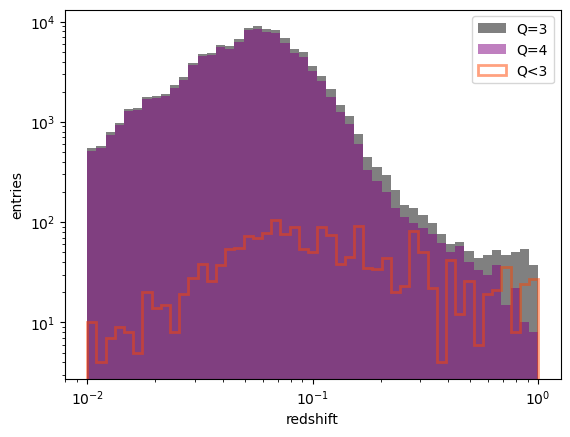

In [233]:
z_bins = np.logspace(-2, 0, 50)
plt.hist(galaxies.z, bins=z_bins, label='Q=3', color='gray')
plt.hist(best_galaxies.z, bins=z_bins, alpha=.5, color='purple', label='Q=4')
plt.hist(bad_galaxies.z, bins=z_bins, alpha=.5, color='orangered', label='Q<3', histtype='step', linewidth=2)

plt.xscale('log')
plt.xlabel('redshift')

plt.yscale('log')
plt.ylabel('entries')

plt.legend(loc=1)

plt.show()

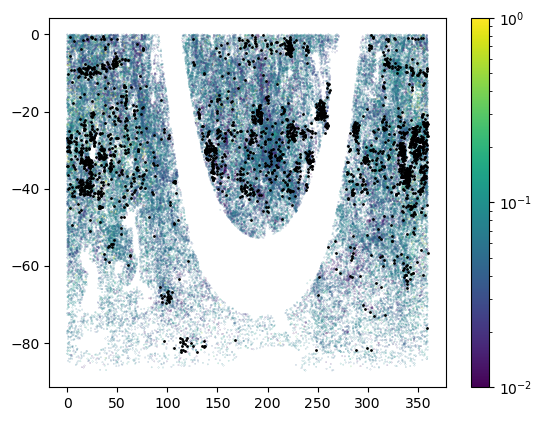

In [234]:
sc = plt.scatter(galaxies.RA, galaxies.DEC, s=0.01, c=galaxies.z, norm='log', vmin=0.01, vmax=1)
plt.scatter(bad_galaxies.RA, bad_galaxies.DEC, s=1, color='black')
plt.colorbar(sc)

In [235]:
bins = [0.03, 0.06, 0.13, 0.23, 0.33, 0.65]
galaxies_binned = []
for i in range(len(bins)-1):
    z_i = galaxies['z'] > bins[i]
    z_ii = galaxies['z'] < bins[i+1]
    galaxies_binned.append(galaxies[z_i * z_ii])

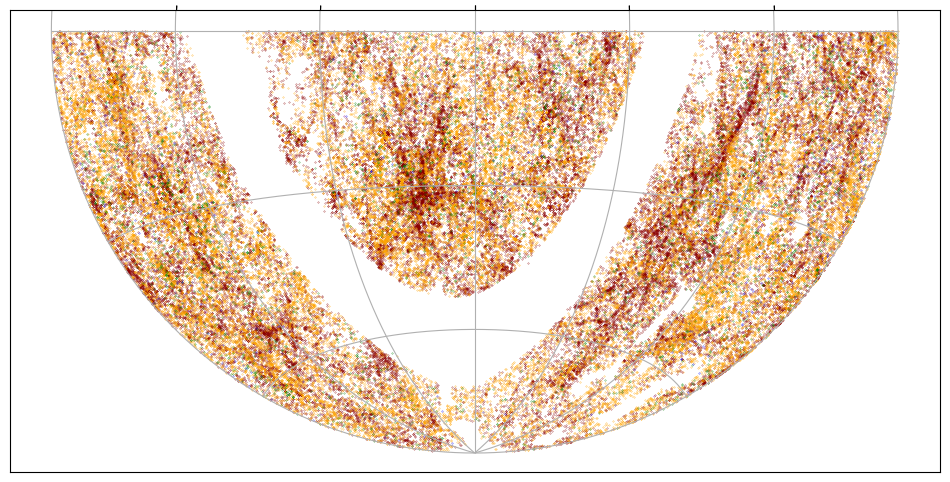

In [236]:
from astropy.wcs import WCS

w = WCS(naxis=2)

w.wcs.crval = [180, 0]   # reference sky position
w.wcs.crpix = [180, 90]          # reference pixel
w.wcs.cdelt = [-1, 1]     # pixel scale (RA negative by convention)
w.wcs.ctype = ["RA---AIT", "DEC--AIT"]  # Aitoff projection


plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection=w)
colors=['darkred', 'orange', 'green', 'blue', 'purple']
for i in range(len(galaxies_binned)):
    gb = galaxies_binned[i]
    sc = plt.scatter(gb.RA, gb.DEC, s=0.05, c=colors[i], transform = ax.get_transform('world')) #, norm='log', vmin=0.01, vmax=1, transform = ax.get_transform('world'))
ax.grid(True)
plt.show()

### Mask (Chat-GPT recipie)

Step 1 — go to HEALPix

In [237]:
import healpy as hp
import numpy as np

nside = 128
npix = hp.nside2npix(nside)

mask = np.zeros(npix)

Step 2 — fill pixels with data

In [238]:
good = (galaxies.z > 0.01) * (galaxies.z <= 0.05)
galaxies = galaxies[good]
ra, dec = np.array(galaxies["RA"]), np.array(galaxies["DEC"])
z = np.array(galaxies["z"])

theta_data = np.radians(90 - dec)
phi_data   = np.radians(ra)

# 1. build mask from catalog
mask = np.zeros(npix)
pix = hp.ang2pix(nside, theta_data, phi_data)
mask[pix] = 1

# 2. smooth / fill
mask = hp.smoothing(mask, sigma=np.radians(2.0))
mask = (mask > 0.1).astype(float)

# 3. apply Galactic cut (pixel space!)
theta_pix, phi_pix = hp.pix2ang(nside, np.arange(npix))
b_pix = 90.0 - np.degrees(theta_pix)

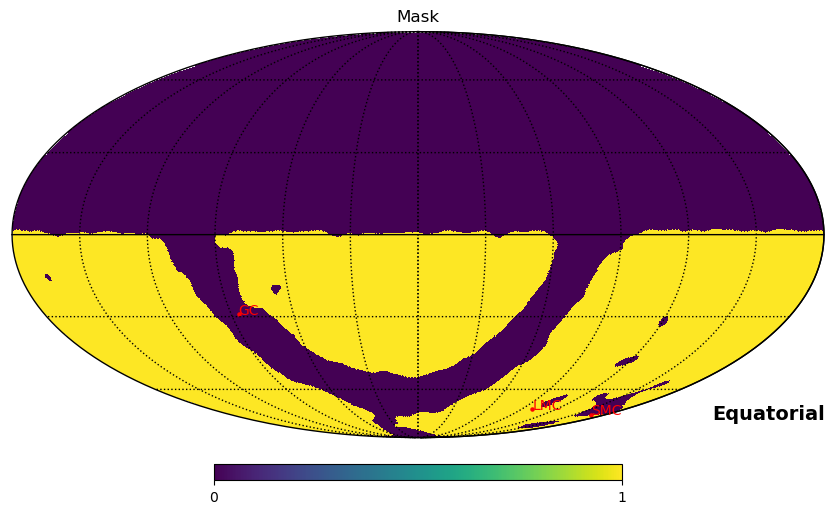

In [239]:
from astropy.coordinates import SkyCoord
import astropy.units as u

hp.mollview(mask, title="Mask", coord='C', rot=(180, 0, 0))

# LMC / SMC Galactic coordinates
l_gal = np.array([0, 280.5, 302.8])
b_gal = np.array([0, -32.9, -44.3])

objects = SkyCoord(l=l_gal, b=b_gal, unit='deg', frame='galactic')

# convert to healpy angles
theta_gal = np.radians(90 - b_gal)
phi_gal   = np.radians(l_gal)

# overplot
hp.projscatter(theta_gal, phi_gal, coord=['G', 'C'], marker='o', color='red', s=5)

# optional labels
hp.projtext(theta_gal[0], phi_gal[0], "GC", coord=['G', 'C'], color='red')
hp.projtext(theta_gal[1], phi_gal[1], "LMC", coord=['G', 'C'], color='red')
hp.projtext(theta_gal[2], phi_gal[2], "SMC", coord=['G', 'C'], color='red')

hp.graticule()
plt.show()

### Distribution in redshifts

In [240]:
from scipy.ndimage import gaussian_filter1d

hist, edges = np.histogram(np.log10(z), bins=50, density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

In [241]:
# GENERATE A RANDOM SOURCE FIELD 
N_rand = 20 * galaxies.z.size
print(galaxies.z.size)

cdf = np.cumsum(nz)
cdf /= cdf[-1]

def sample_z(N):
    u = np.random.rand(N)
    return np.interp(u, cdf, z_centers)

z_rand = 10**sample_z(N_rand)

48969


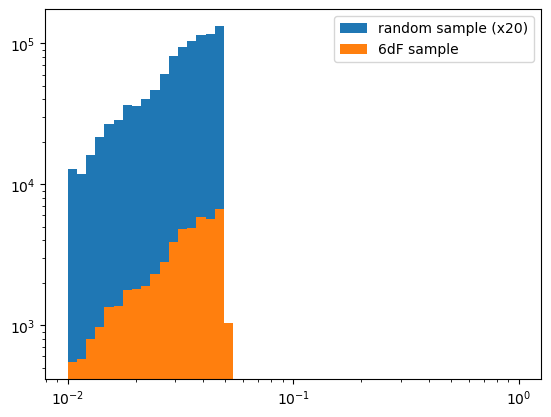

In [242]:
plt.hist(z_rand, bins=z_bins, label='random sample (x20)')
plt.hist(galaxies.z, bins=z_bins, label='6dF sample')
plt.legend()
plt.yscale('log')
plt.xscale('log')

### Combine with the mask

In [243]:
# distributing random sources in the sky

prob = mask.astype(float)
prob /= prob.sum()   # normalize

# draw pixel indices
npix = len(mask)
pix_rand = np.random.choice(np.arange(npix), size=N_rand, p=prob)

# convert to angles
theta_pix, phi_pix = hp.pix2ang(nside, pix_rand)

# pixel size
res = hp.nside2resol(nside)

# add sub-pixel jitter
theta_rand = theta_pix + np.random.uniform(-res/2, res/2, size=N_rand)
phi_rand   = phi_pix   + np.random.uniform(-res/2, res/2, size=N_rand)

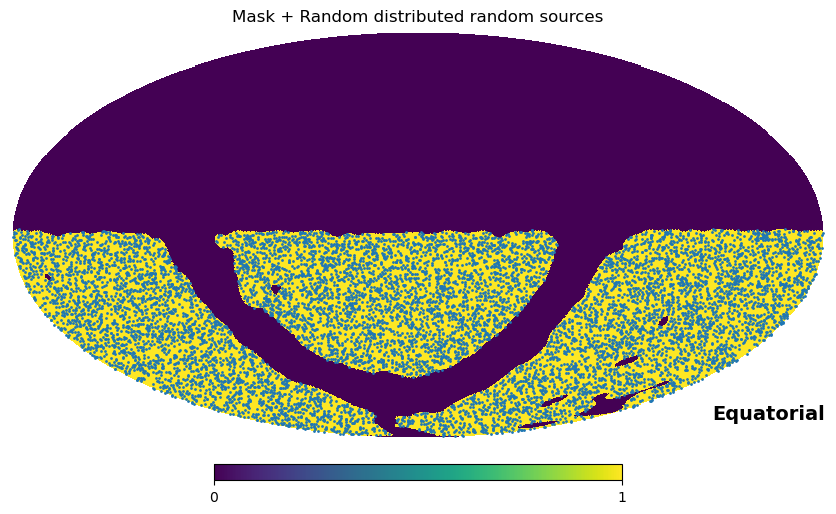

In [244]:
# sanity check of the randomly distributed sources
hp.mollview(mask, title="Mask + Random distributed random sources", rot=(180, 0, 0), coord='C')
hp.projscatter(theta_rand[:10000], phi_rand[:10000], s=1)
plt.show()

In [245]:
pix_test = hp.ang2pix(nside, theta_rand, phi_rand)
np.unique(pix_test, return_counts=True)

(array([ 93978,  93980,  93981, ..., 196530, 196547, 196552]),
 array([1, 2, 1, ..., 2, 1, 1]))

### Plot overdensity

In [246]:
# OVERDENSITY VALUE

npix = hp.nside2npix(nside)

# data
pix_d = hp.ang2pix(nside, theta_data, phi_data)
counts_d = np.bincount(pix_d, minlength=npix)

# randoms
pix_r = hp.ang2pix(nside, theta_rand, phi_rand)
counts_r = np.bincount(pix_r, minlength=npix)

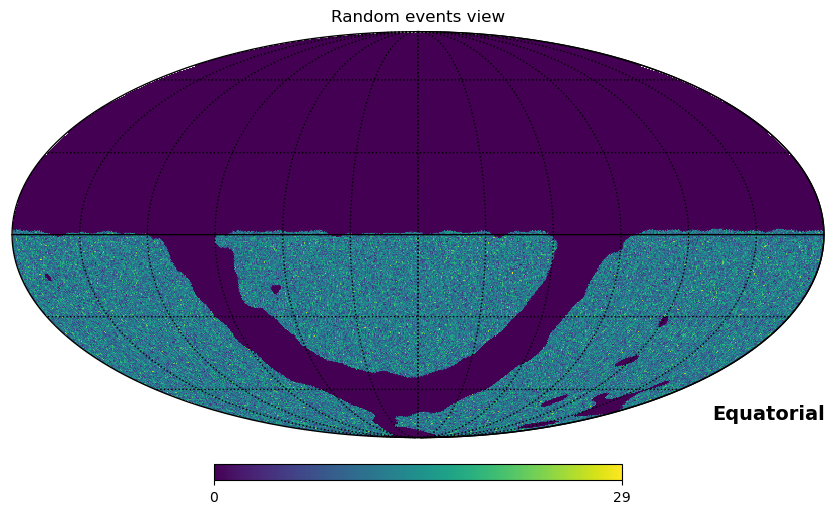

In [247]:
hp.mollview(counts_r, title="Random events view", rot=(180, 0, 0), coord='C')
hp.graticule()

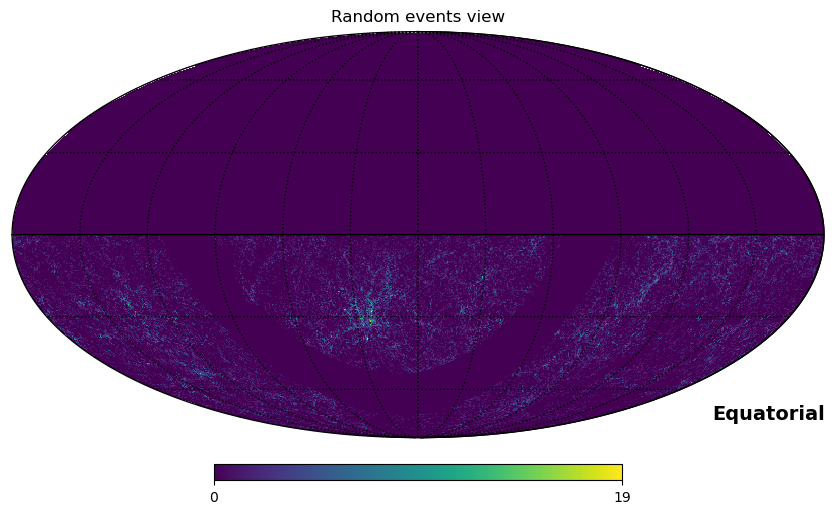

In [248]:
hp.mollview(counts_d, title="Random events view", rot=(180, 0, 0), coord='C')
hp.graticule()

In [249]:
print(f"SAMPLE DENSITY: {galaxies.z.size / sum(mask)}")
print(f"RANDOM DENSITY: {N_rand / sum(mask)}")

SAMPLE DENSITY: 0.5981165722102795
RANDOM DENSITY: 11.962331444205589


In [250]:
# normalization coefficient (data / sampling)
alpha = len(theta_data) / len(theta_rand)

# OVERDENSITY FUNCTION
delta = np.zeros(npix, dtype=float)

valid = counts_r > 0
delta[valid] = counts_d[valid] / (alpha * counts_r[valid]) - 1

delta_s = hp.smoothing(delta, sigma=np.radians(1.0)) * mask

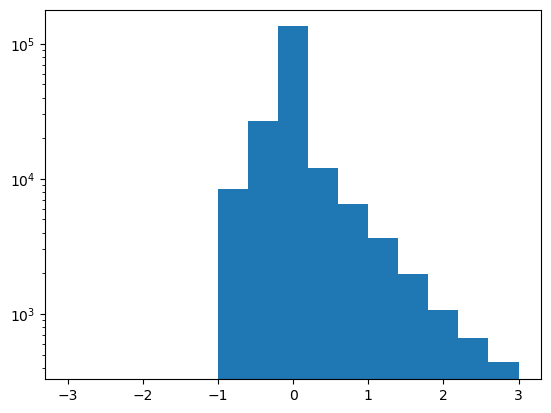

In [251]:
plt.hist(delta_s.ravel(), bins = [-3.0, -2.6, -2.2, -1.8, -1.4, -1, -0.6, -0.2, 0.2, 0.6, 1., 1.4, 1.8, 2.2, 2.6, 3.0])
plt.yscale('log')

In [252]:
print(np.nanmean(delta[valid]))   # should be ~0
print(np.nanstd(delta[valid]))    # reasonable scatter

0.09855417905301882
2.246413726488696


In [253]:
print(np.nanmean(delta_s[valid]))   # should be ~0
print(np.nanstd(delta_s[valid]))    # reasonable scatter

0.11605337805140928
0.8332952768039382


In [ ]:
np.save("6df-overdensity-z-l005", delta * mask)

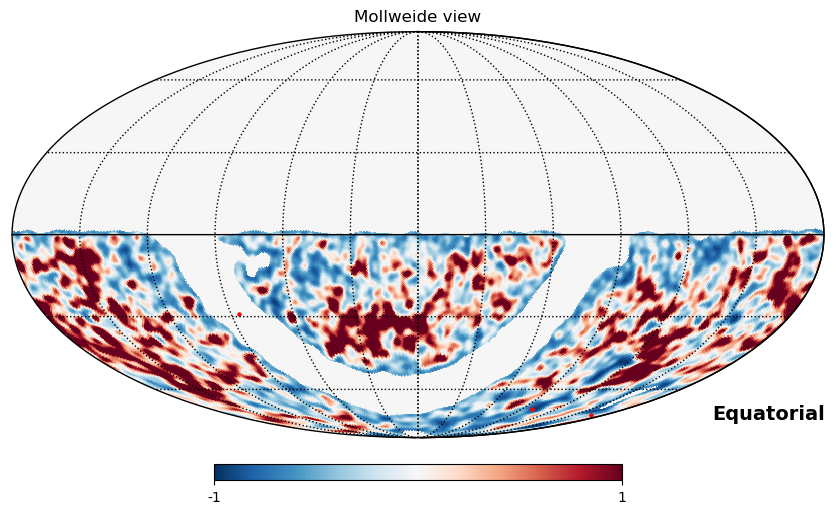

In [194]:
hp.mollview(delta_s * mask, cmap='RdBu_r', min=-1, max=1, rot=(180, 0, 0), coord='C')
hp.projscatter(theta_gal, phi_gal, coord=['G', 'C'], marker='o', color='red', s=5)
hp.graticule()

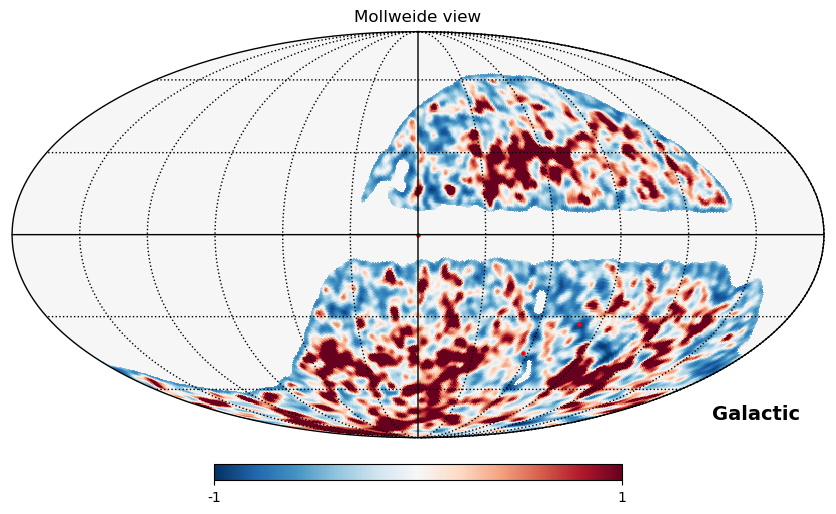

In [195]:
hp.mollview(delta_s * mask, coord=['C', 'G'], cmap='RdBu_r', min=-1, max=1)
hp.projscatter(theta_gal, phi_gal, coord='G', marker='o', color='red', s=5)
hp.graticule()

### ONLY SOUTHERN SKY

In [88]:
# grid resolution (increase for smoother maps)
nra = 3600
ndec = 1800

# ra in radians [-pi, pi]
ra = np.linspace(-np.pi, np.pi, nra)

# dec in radians [-pi/2, pi/2]
dec = np.linspace(-np.pi/2, np.pi/2, ndec)

RA, DEC = np.meshgrid(ra, dec)
ra_deg, dec_deg = np.rad2deg(ra), np.rad2deg(dec)

In [89]:
# longitude = phi, latitude = pi/2 - theta
theta_g = np.pi/2 - DEC
phi_g   = RA

nside = hp.get_nside(delta_s)

pix = hp.ang2pix(nside, theta_g.ravel(), phi_g.ravel())
grid_gal = delta_s[pix].reshape(ndec, nra)

In [90]:
def shift_ra_minus180_to_0_360(image):
    """
    Shift RA axis from [-180, 180] to [0, 360] by rolling the array.
    Assumes RA is along axis=1.
    """

    ny, nx = image.shape

    # midpoint corresponds to RA = 0
    split = nx // 2

    # roll array so that [0, 360] starts at former 0 position
    shifted = np.roll(image, -split, axis=1)

    return shifted

grid_gal2 = shift_ra_minus180_to_0_360(grid_gal)
ra_real = ra_deg + 180

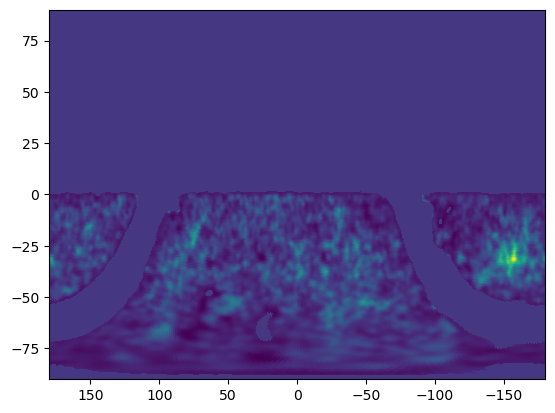

In [91]:
plt.pcolormesh(ra_deg, dec_deg, grid_gal)
plt.gca().invert_xaxis()
plt.show()

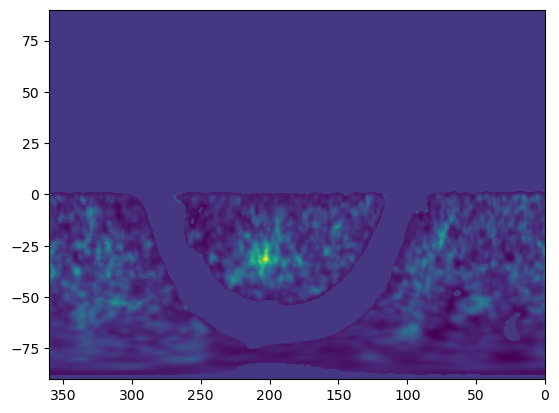

In [92]:
plt.pcolormesh(ra_real, dec_deg, grid_gal2)
plt.gca().invert_xaxis()
plt.show()

In [93]:
ra_dist = np.linspace(0, 360, 10)
dec_dist = np.linspace(-80, 80, 5)

ra_g, dec_g = np.meshgrid(ra_dist, dec_dist, indexing='ij')

In [94]:
ra_to_plot = np.linspace(0, 360, ra_real.size+1, endpoint=True)
dec_to_plot = np.linspace(-90, 90, dec_deg.size+1, endpoint=True)

In [95]:
# sources = pd.read_csv("Neronov_Catalogue/total.csv")
# sources_detected = pd.read_csv("Neronov_Catalogue/IACT_Detected.txt", delimiter='\t')
# sources_4sigma = pd.read_csv("Neronov_Catalogue/VHE_4_sigma.txt", delimiter='\t')

In [96]:
# sources = sources[sources['HSP'] == "E"]
# sources_detected = sources_detected[sources_detected['HSP'] == "E"]
# sources_4sigma = sources_4sigma[sources_4sigma['HSP'] == "E"]

In [97]:
# sources_z = np.float32(sources['z'])

In [98]:
# w = WCS(naxis=2)
# nx, ny = 360, 180

# w.wcs.crval = [180, 0]   # reference sky position
# w.wcs.crpix = [nx//2, 0]          # reference pixel
# w.wcs.cdelt = [-360/nx, 180/ny]     # pixel scale (RA negative by convention)
# proj = "AIT"
# w.wcs.ctype = [f"RA---{proj}", f"DEC--{proj}"]  # Aitoff projection

# fig = plt.figure(figsize=(12, 6))
# ax = plt.subplot(111, projection=w)

# im = ax.pcolormesh(ra_to_plot, dec_to_plot, grid_gal2,
#                    cmap='RdBu_r', vmin=-2, vmax=2,
#                    transform=ax.get_transform('world'),
#                    rasterized=True)
# c = ax.contour(ra_real, dec_deg, grid_gal2,
#            levels=[1, 2, 4],
#            norm='log', linewidth=0.5,
#            transform=ax.get_transform('world'))
# ax.clabel(c)

# xs, ys = w.wcs_world2pix(sources["RA"], sources["Dec"], 0)
# ax.scatter(xs, ys, s=5, color='black', label='all')
# for i in range(len(sources)):
#     if ys[i] > 0:
#         continue
#     ax.text(xs[i], ys[i], sources_z[i])
# ax.scatter(sources_detected["RA"], sources_detected["Dec"], s=12, transform=ax.get_transform('world'), color='green', label='detected')
# ax.scatter(sources_4sigma["RA"], sources_4sigma["Dec"], s=40, marker='*', transform=ax.get_transform('world'), color='red', label='targets')

# ax.grid(True)
# ax.set_title("6dF LSS 0.01 < z < 0.15", y=1.07, loc='center')

# ax.set_xlabel("")
# ax.set_ylabel("dec")
# ylim_coords = w.wcs_world2pix(0, -90, 0)

# ax.set_xlim(10, nx-10)
# ax.set_ylim(ylim_coords[1], 0)

# ax.legend(loc=3)
# plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, aspect=50, label='overdensity')
# plt.show()